In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/European_Bank.csv")

In [3]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [7]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop(['CustomerId', 'Surname'], axis=1, inplace=True)

In [11]:
print(df['HasCrCard'].unique())
print(df['IsActiveMember'].unique())
print(df['Exited'].unique())

[1 0]
[1 0]
[1 0]


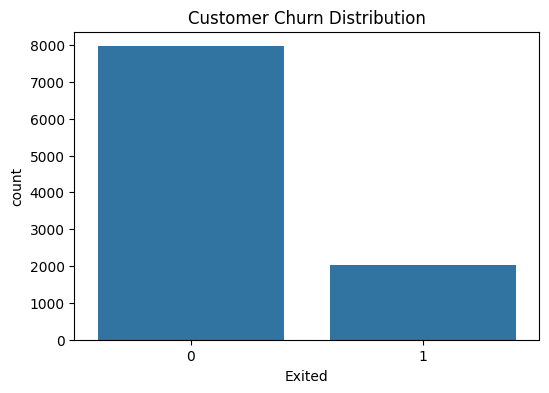

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x='Exited', data=df)

plt.title("Customer Churn Distribution")
plt.show()

Most customers are retained, but a significant portion has churned, indicating the need for retention-focused strategies.

In [13]:
churn_rate = df['Exited'].mean()*100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 20.37%


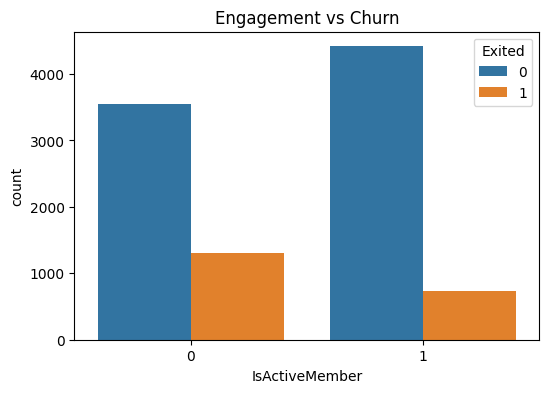

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x='IsActiveMember', hue='Exited', data=df)

plt.title("Engagement vs Churn")
plt.show()

Inactive customers show significantly higher churn compared to active customers.

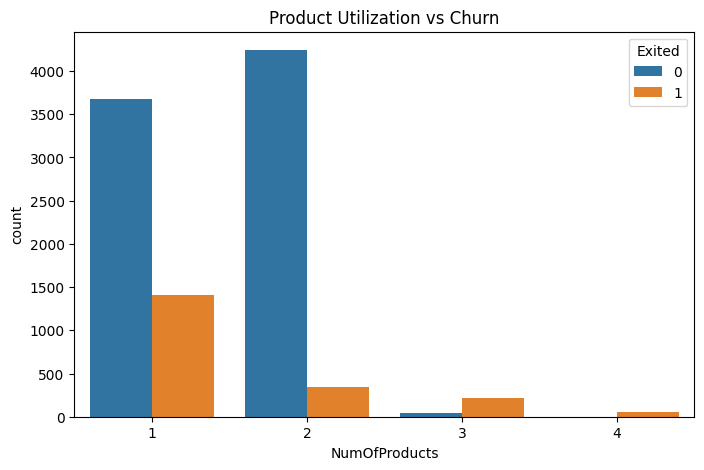

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(x='NumOfProducts', hue='Exited', data=df)

plt.title("Product Utilization vs Churn")
plt.show()

Customers with multiple products generally exhibit better retention behavior.

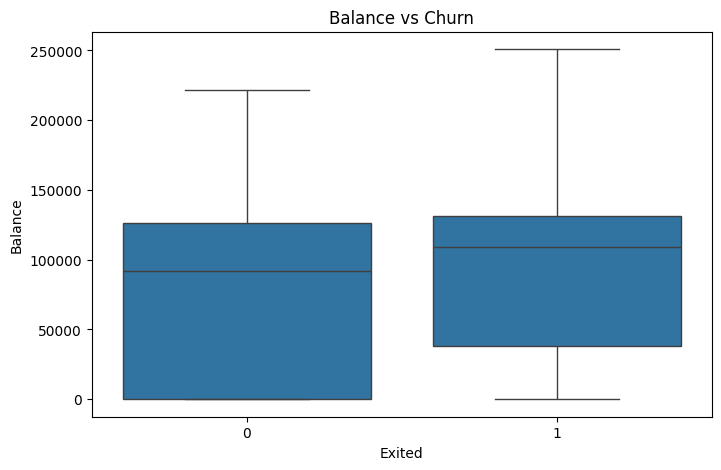

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Exited', y='Balance', data=df)

plt.title("Balance vs Churn")
plt.show()

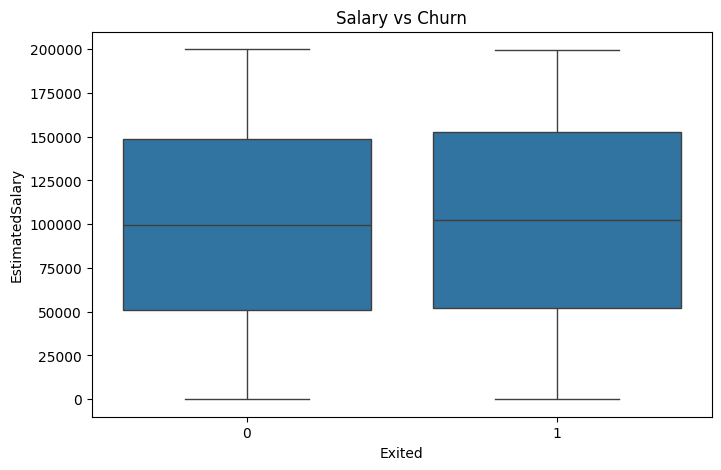

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Exited', y='EstimatedSalary', data=df)

plt.title("Salary vs Churn")
plt.show()

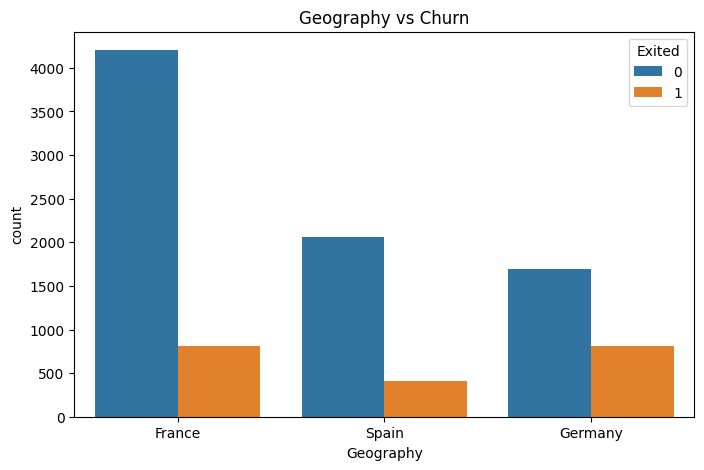

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(x='Geography', hue='Exited', data=df)

plt.title("Geography vs Churn")
plt.show()

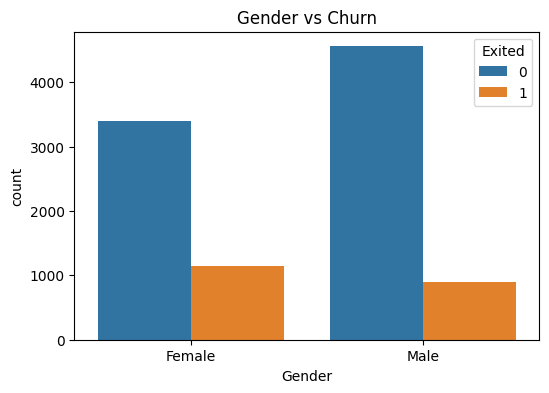

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', hue='Exited', data=df)

plt.title("Gender vs Churn")
plt.show()

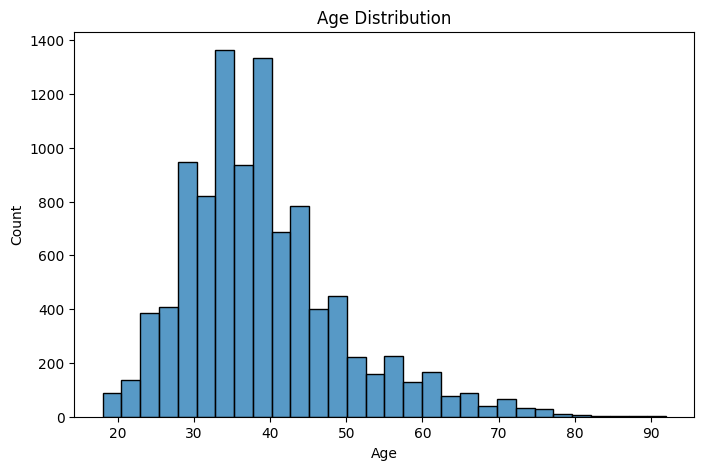

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30)

plt.title("Age Distribution")
plt.show()

In [25]:
df['EngagementScore'] = (
    df['IsActiveMember'] * 40 +
    df['HasCrCard'] * 20 +
    df['NumOfProducts'] * 10 +
    df['Tenure'] * 3
)

In [26]:
df['ProductDepthIndex'] = (
    df['NumOfProducts'] * 25
)

In [27]:
df['RelationshipStrength'] = (
    df['EngagementScore'] +
    df['ProductDepthIndex']
)

In [28]:
df['HighValueDisengaged'] = np.where(
    (df['Balance'] > 100000) &
    (df['IsActiveMember'] == 0),
    1,
    0
)

In [29]:
active_churn = df[df['IsActiveMember']==1]['Exited'].mean()

inactive_churn = df[df['IsActiveMember']==0]['Exited'].mean()

print("Active Churn:", active_churn)
print("Inactive Churn:", inactive_churn)

Active Churn: 0.14269073966220153
Inactive Churn: 0.26850897092183956


In [30]:
product_churn = df.groupby('NumOfProducts')['Exited'].mean()

print(product_churn)

NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64


In [31]:
premium_risk = df[
    (df['Balance'] > 100000) &
    (df['Exited']==1)
]

print("High Balance Churn Customers:", len(premium_risk))

High Balance Churn Customers: 1211


In [32]:
df.groupby('Exited')['RelationshipStrength'].mean()

Exited
0    105.474695
1     94.844870
Name: RelationshipStrength, dtype: float64

In [33]:
def segment_customer(row):

    if row['IsActiveMember']==1 and row['NumOfProducts'] >= 2:
        return "Highly Engaged"

    elif row['IsActiveMember']==0 and row['Balance'] > 100000:
        return "Silent Risk"

    elif row['NumOfProducts']==1:
        return "Low Product User"

    else:
        return "Moderate"

df['CustomerSegment'] = df.apply(segment_customer, axis=1)

In [34]:
df['CustomerSegment'].value_counts()

CustomerSegment
Low Product User    3507
Highly Engaged      2588
Silent Risk         2356
Moderate            1549
Name: count, dtype: int64

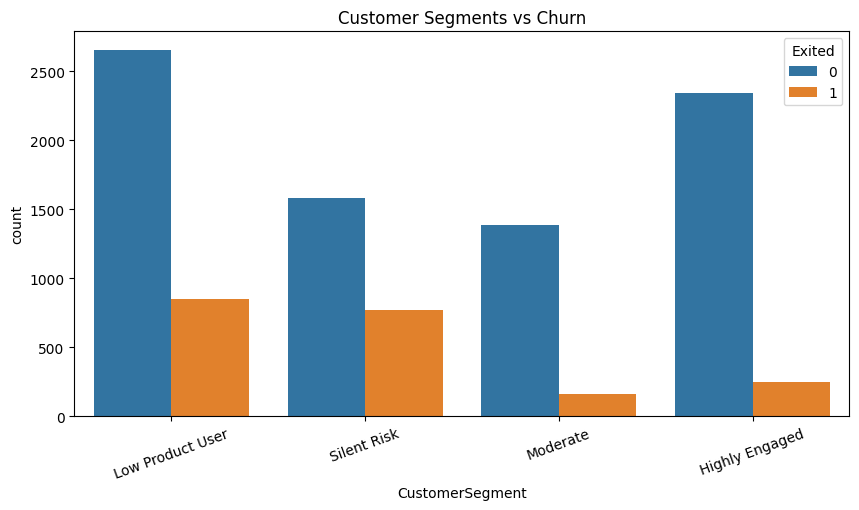

In [35]:
plt.figure(figsize=(10,5))

sns.countplot(x='CustomerSegment', hue='Exited', data=df)

plt.title("Customer Segments vs Churn")
plt.xticks(rotation=20)
plt.show()

In [36]:
df_ml = pd.get_dummies(df, drop_first=True)

In [37]:
X = df_ml.drop('Exited', axis=1)

y = df_ml['Exited']

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [40]:
y_pred = model.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8695
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      1607
           1       0.76      0.49      0.60       393

    accuracy                           0.87      2000
   macro avg       0.82      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



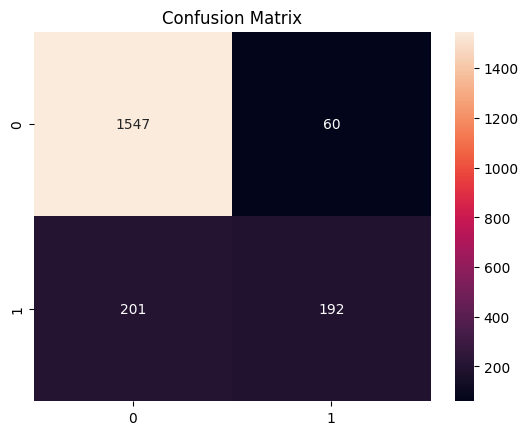

In [42]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.show()

In [43]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
2,Age,0.223803
8,EstimatedSalary,0.122155
4,Balance,0.118820
1,CreditScore,0.118579
11,RelationshipStrength,0.087478
9,EngagementScore,0.063057
10,ProductDepthIndex,0.054834
5,NumOfProducts,0.048116
3,Tenure,0.047202
13,Geography_Germany,0.027403


In [45]:
df.to_csv("../outputs/reports/cleaned_churn.csv", index=False)